In [7]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts

In [8]:
df = pl.read_parquet("../final_patient_data.parquet")

In [9]:
df.head()

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,anti_aldosterone,furosemide,gender,birth_date,death_date,age_at_admission,comorbidity_score,hfrs_score,OMT_component_score,death_flag
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,date,i32,f64,f64,i8,i32
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,"""F""",1933-04-12,2018-09-21,85,0.0,0.0,2,1
"""P002""",2002,"""brest""",2019-01-18 13:20:00,2019-01-25 11:00:00,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,"""M""",1934-11-03,null,84,0.0,0.0,0,0
"""P003""",3002,"""nantes""",2019-04-09 09:15:00,2019-04-18 10:30:00,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,1,"""F""",1935-07-26,2020-12-04,83,3.0,1.4,2,1
"""P004""",4002,"""tours""",2018-03-03 07:50:00,2018-03-18 12:20:00,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,"""M""",1936-02-18,null,82,0.0,0.0,1,0
"""P005""",5002,"""angers""",2019-02-01 14:10:00,2019-02-08 15:00:00,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,"""F""",1937-09-09,2019-03-17,81,2.0,0.0,0,1


In [10]:
df = df.select(["patient_id", "hosp_admission_datetime", "death_date", "icu_stay_flag"])

In [11]:
df.shape

(10, 4)

In [12]:
df = df.to_pandas()

In [13]:
df.head()

,patient_id,hosp_admission_datetime,death_date,icu_stay_flag
0,P001,2018-07-04 11:15:00,2018-09-21,0
1,P002,2019-01-18 13:20:00,NaT,0
2,P003,2019-04-09 09:15:00,2020-12-04,0
3,P004,2018-03-03 07:50:00,NaT,1
4,P005,2019-02-01 14:10:00,2019-03-17,0


In [14]:
# Convert to datetime and then extract the date only
# Normalize the time component to 00:00:00
df["hosp_admission_datetime"] = pd.to_datetime(df["hosp_admission_datetime"]).dt.normalize()
df["death_date"] = pd.to_datetime(df["death_date"]).dt.normalize()

In [15]:
df.head()

,patient_id,hosp_admission_datetime,death_date,icu_stay_flag
0,P001,2018-07-04,2018-09-21,0
1,P002,2019-01-18,NaT,0
2,P003,2019-04-09,2020-12-04,0
3,P004,2018-03-03,NaT,1
4,P005,2019-02-01,2019-03-17,0


In [16]:
# Create a one-year follow-up limit for each patient (admission date + 365 days)
df["one_year_limit"] = df["hosp_admission_datetime"]+pd.Timedelta(days=365)

In [17]:
# Define the actual end of follow-up for each patient:
# use the death date if available; otherwise, use the one-year limit
df["end_followup"] = df["death_date"].fillna(df["one_year_limit"])

# If the death date is beyond the one-year limit, censor follow-up at the one-year limit
df.loc[df["end_followup"] > df["one_year_limit"], "end_followup"] = (df["one_year_limit"])

In [18]:
# Calculate the elapsed follow-up time in days
# This is the time variable used in the Kaplan-Meier estimator
df["time"] = (
    df["end_followup"]-df["hosp_admission_datetime"]
).dt.days

In [19]:
df.head()

,patient_id,hosp_admission_datetime,death_date,icu_stay_flag,one_year_limit,end_followup,time
0,P001,2018-07-04,2018-09-21,0,2019-07-04,2018-09-21,79
1,P002,2019-01-18,NaT,0,2020-01-18,2020-01-18,365
2,P003,2019-04-09,2020-12-04,0,2020-04-08,2020-04-08,365
3,P004,2018-03-03,NaT,1,2019-03-03,2019-03-03,365
4,P005,2019-02-01,2019-03-17,0,2020-02-01,2019-03-17,44


In [20]:
# Determine whether death occurred within this follow-up period
# This is the status/event variable
df["status"] = (df["death_date"].notna()) & (
    df["death_date"] < df["one_year_limit"]
)

In [21]:
df[df['time']<0]

,patient_id,hosp_admission_datetime,death_date,icu_stay_flag,one_year_limit,end_followup,time,status


In [22]:
df[df['time']==0].shape

(0, 8)

In [23]:
df[df['time']==0]

,patient_id,hosp_admission_datetime,death_date,icu_stay_flag,one_year_limit,end_followup,time,status


In [24]:
df = df[df['time']>= 0]

In [25]:
df[df['time']<0]

,patient_id,hosp_admission_datetime,death_date,icu_stay_flag,one_year_limit,end_followup,time,status


In [26]:
df["patient_id"].nunique()

10

In [28]:
from lifelines.utils import survival_table_from_events

monthly_intervals = np.linspace(0, 365, 13)

# Create a survival event table by aggregating deaths and censoring
# into approximately monthly intervals over the one-year follow-up period
monthly_table = survival_table_from_events(
    death_times=df["time"],          # Follow-up time in days for each patient
    event_observed=df["status"],     # Event indicator: 1 = death, 0 = censored
    collapse=True,                   # Aggregate observations into defined intervals
    intervals=monthly_intervals      # Boundaries of the approximately monthly intervals
)


# Reset the row index after creating the monthly survival table
# and discard the previous interval-based index
monthly_table = monthly_table.reset_index(drop=True)

monthly_table['month'] = range(1, len(monthly_table) + 1)

monthly_table = monthly_table[
    ['month', "at_risk", "observed", "censored", "removed"]
]

monthly_table

,month,at_risk,observed,censored,removed
0,1,10,1,0,1
1,2,9,1,0,1
2,3,8,1,0,1
3,4,7,0,0,0
4,5,7,0,0,0
5,6,7,0,0,0
6,7,7,1,0,1
7,8,6,0,0,0
8,9,6,0,0,0
9,10,6,0,0,0


In [32]:
kmf = KaplanMeierFitter()
kmf.fit(df['time'], event_observed = df['status'])
kmf.survival_function_

,KM_estimate
timeline,
0.0,1.0
21.0,0.9
44.0,0.8
79.0,0.7
209.0,0.6
365.0,0.6


<Axes: xlabel='timeline'>

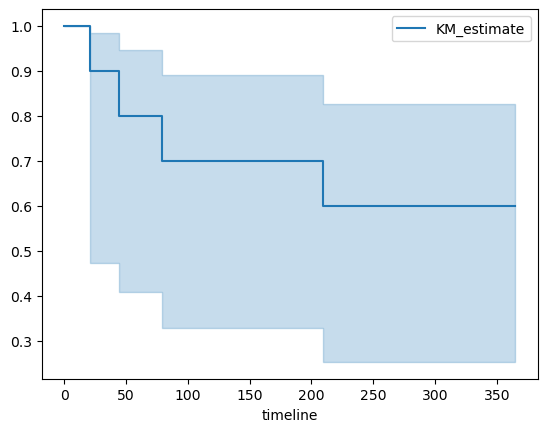

In [33]:
kmf.plot_survival_function()

In [36]:
df["icu_stay_flag"].value_counts(dropna=False)

icu_stay_flag
0    8
1    2
Name: count, dtype: int64

In [37]:
df["status"].value_counts(dropna=False)

status
False    6
True     4
Name: count, dtype: int64

In [39]:
df = df[['patient_id', 'time', 'status', 'icu_stay_flag']].dropna().copy()

In [29]:
icu_mask = df["icu_stay_flag"]== 1
non_icu_mask =df["icu_stay_flag"]== 0

In [46]:
print("ICU:", icu_mask.sum())
print("Non-ICU:", non_icu_mask.sum())

ICU: 2
Non-ICU: 8


In [30]:
table_2x2 = pd.DataFrame(
    {
        "Event": [
            df.loc[icu_mask, "status"].sum(),
            df.loc[non_icu_mask, "status"].sum()
        ],
        "Censored": [
            (~df.loc[icu_mask, "status"]).sum(),
            (~df.loc[non_icu_mask, "status"]).sum()
        ]
    },
    index=["ICU", "Non-ICU"]
)

table_2x2["Total"] = table_2x2.sum(axis=1)

table_2x2.loc["Total"] = table_2x2.sum(axis=0)

table_2x2

,Event,Censored,Total
ICU,1,1,2
Non-ICU,3,5,8
Total,4,6,10


In [33]:
kmf_icu = KaplanMeierFitter()
kmf_non_icu = KaplanMeierFitter()

kmf_icu.fit(
    durations = df.loc[icu_mask, "time"], 
    event_observed = df.loc[icu_mask, "status"],
    label = "ICU"
)

kmf_non_icu.fit(
    durations = df.loc[non_icu_mask, "time"], 
    event_observed = df.loc[non_icu_mask, "status"],
    label = "Non_ICU"
)

<lifelines.KaplanMeierFitter:"Non_ICU", fitted with 8 total observations, 5 right-censored observations>

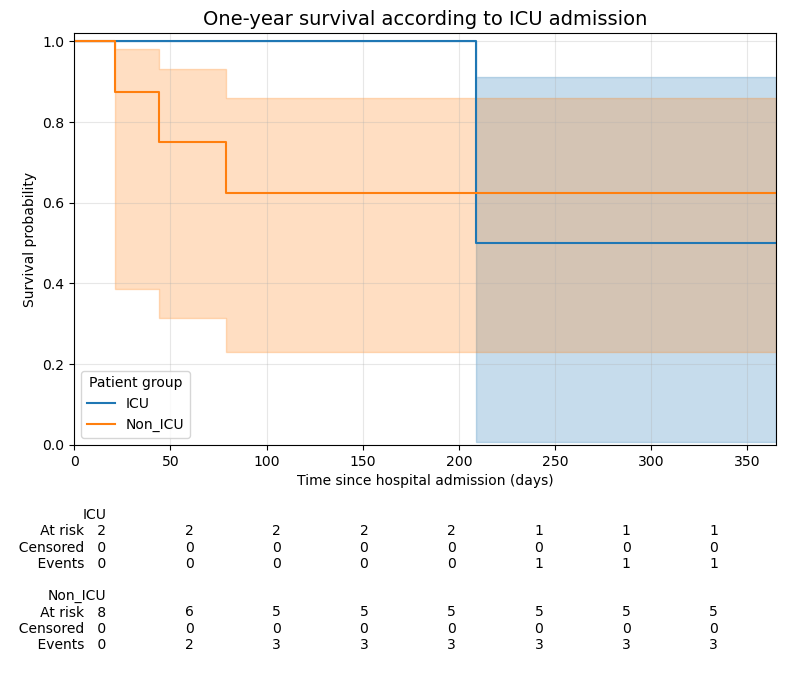

In [34]:
fig, ax = plt.subplots(figsize = (8, 6))

kmf_icu.plot_survival_function(
    ax = ax,
    ci_show = True
)

kmf_non_icu.plot_survival_function(
    ax=ax,
    ci_show=True
)

add_at_risk_counts(
    kmf_icu,
    kmf_non_icu,
    ax=ax
)

ax.set_xlim(0, 365)
ax.set_ylim(0, 1.02)
ax.set_title(
    "One-year survival according to ICU admission",
    fontsize=14
)

ax.set_xlabel("Time since hospital admission (days)")
ax.set_ylabel("Survival probability")
ax.grid(alpha=0.3)
ax.legend(title="Patient group")

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

plt.show()